<a href="https://colab.research.google.com/github/Olya-Shulga/Univercity/blob/main/neural_networks/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [51]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
data = raw_df.values[1::2, 2]

# Восстанавливаем признаки (X), т.к. переменная data перезаписана ценами
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = data

print(f"Данные загружены: {X.shape[0]} записей, {X.shape[1]} признаков")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3215/3116129512.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Данные загружены: 506 записей, 13 признаков


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import gradio as gr

#### 1.2. Проектируем архитектуру для этой задачи

In [53]:
model = Sequential([
    Dense(32, input_shape=(X.shape[1],), activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')  # linear для регрессии
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [54]:
model.compile(
    optimizer='sgd',
    loss='mse',
    metrics=['mae']
)

print("Модель скомпилирована!")

Модель скомпилирована!


#### 1.4. Обучаем модель ИНС

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Первое обучение (без масштабирования)...")
model.fit(X_train, y_train, epochs=10, verbose=1)

Первое обучение (без масштабирования)...
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: nan - mae: nan
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - mae: nan 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: nan - mae: nan 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mae: nan 


In [56]:
print("Модель обучается плохо без масштабирования. Масштабируем данные...")

scaler = MinMaxScaler()  # Масштабирование в диапазон 0-1
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)

# Сохранение модели scaler
with open("scaler_boston.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler сохранен в scaler_boston.pkl")

# Создаем новую модель для масштабированных данных
model = Sequential([
    Dense(16, input_shape=(13,), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')  # linear для регрессии
])

model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

# Сохраняем историю обучения для графиков
history = model.fit(
    X_train_n, y_train,
    epochs=200,
    validation_data=(X_test_n, y_test),  # Валидация на тесте
    verbose=1
)


Модель обучается плохо без масштабирования. Масштабируем данные...
Scaler сохранен в scaler_boston.pkl
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 474.4469 - mae: 19.2411 - val_loss: 387.1748 - val_mae: 17.7168
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 297.6859 - mae: 14.1881 - val_loss: 117.3655 - val_mae: 8.0880
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 78.4357 - mae: 6.4514 - val_loss: 40.4849 - val_mae: 4.3984
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 81.0559 - mae: 6.6445 - val_loss: 43.3305 - val_mae: 4.3616
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 64.3852 - mae: 5.8439 - val_loss: 42.9351 - val_mae: 4.4972
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 48.3981 - mae: 4.8838 - val_loss: 55.0690 - val_mae: 6.4039
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 45.0185 - mae: 4.9011 - val_loss: 32.8410 - val_mae: 3.6479
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38.7583 - mae: 4.4737 - val_loss: 73.4924 - val_mae: 6.2436
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

#### 1.6. Делаем предсказания на тестовых данных

In [57]:
preds = model.predict(X_test_n, verbose=0)

print(f"Количество предсказаний: {len(preds)}")

Количество предсказаний: 102


#### 1.7. Вычисляем метрику качества на тестовых данных

In [58]:
mae = mean_absolute_error(preds, y_test)
print(f"Метрика качества (MAE): {mae:.4f} ($1000)")
print(f"Средняя ошибка модели: ${mae*1000:.2f}")

Метрика качества (MAE): 3.6494 ($1000)
Средняя ошибка модели: $3649.42


#### 1.8. Строим график обучения

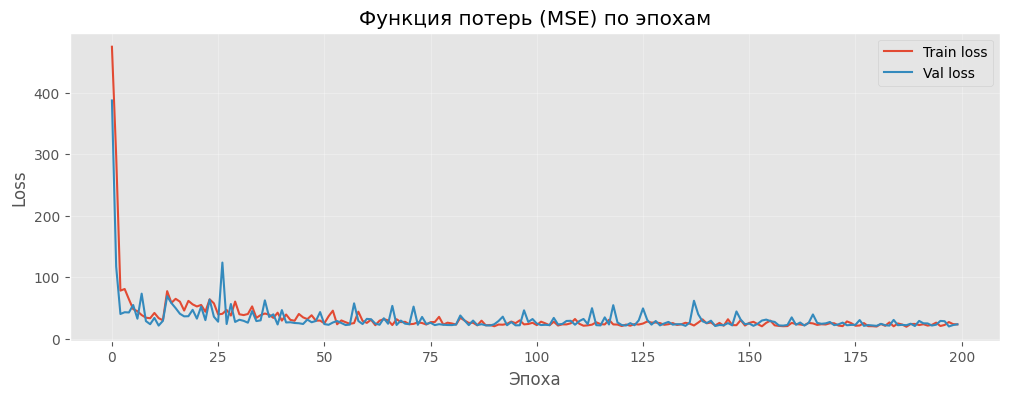

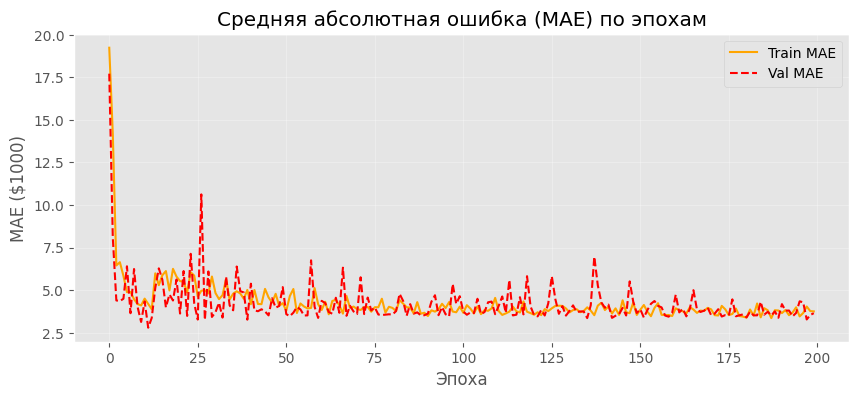

In [59]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Функция потерь (MSE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Дополнительно: график MAE
plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='Train MAE', color='orange')
plt.plot(history.history['val_mae'], label='Val MAE', color='red', linestyle='--')
plt.title('Средняя абсолютная ошибка (MAE) по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MAE ($1000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [61]:
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

def preprocess_input(features, scale_model="scaler_boston.pkl"):
    """
    Функция преобразует входные данные в формат, подходящий для модели.
    (Адаптировано из примера California Housing)
    """
    try:
        features = np.array(features)
        if not features.size:
            raise ValueError("Пустой массив признаков!")
        features = features.reshape(1, -1)

        with open(scale_model, "rb") as f:
            scaler = pickle.load(f)

        features = scaler.transform(features)
    except Exception as e:
        raise ValueError(f"Ошибка при предобработке: {e}")

    return features

def predict_price(*features):
    """
    Функция прогнозирует цену на основе входных признаков.
    (Адаптировано из примера California Housing)
    """
    try:
        features = preprocess_input(features)
        prediction = model.predict(features, verbose=0)

        if np.isnan(prediction).any():
            raise ValueError("Ошибка при прогнозировании: NaN")
    except Exception as e:
        raise ValueError(f"Ошибка при прогнозировании: {e}")

    # Возвращение прогнозируемой цены (в долларах)
    return f"Прогнозируемая цена: ${prediction[0][0]*1000:,.2f}"


# Графичекий интерфейс
interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Slider(label="CRIM (преступность)", minimum=0, maximum=100, step=0.1, value=0.1),
        gr.Slider(label="ZN (земли под застройку)", minimum=0, maximum=100, step=0.1, value=20),
        gr.Slider(label="INDUS (торговые площади)", minimum=0, maximum=30, step=0.1, value=5),
        gr.Slider(label="CHAS (близость к реке)", minimum=0, maximum=1, step=1, value=0),
        gr.Slider(label="NOX (оксиды азота)", minimum=0.3, maximum=0.9, step=0.01, value=0.5),
        gr.Slider(label="RM (число комнат)", minimum=3, maximum=9, step=0.1, value=6.5),
        gr.Slider(label="AGE (дома до 1940)", minimum=0, maximum=100, step=1, value=60),
        gr.Slider(label="DIS (расстояние до центра)", minimum=1, maximum=12, step=0.1, value=4),
        gr.Slider(label="RAD (доступность дорог)", minimum=1, maximum=24, step=1, value=4),
        gr.Slider(label="TAX (налог)", minimum=187, maximum=711, step=1, value=300),
        gr.Slider(label="PTRATIO (ученики/учителя)", minimum=12, maximum=22, step=0.1, value=15),
        gr.Slider(label="B (индекс)", minimum=0, maximum=400, step=1, value=390),
        gr.Slider(label="LSTAT (низкий статус %)", minimum=1, maximum=40, step=0.1, value=10),
    ],
    live=True,  # Обновление при каждом изменении слайдера
    outputs=gr.Text(label="Predicted Price ($)"),
)

# Запуск интерфейса (в стиле преподавателя)
interface.launch(debug=False, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://19a25c94076b9ba939.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
print("\n" + "="*60)
print("ПРОВЕРКА МОДЕЛИ НА ПРИМЕРЕ КОНКРЕТНОГО ДОМА")
print("="*60)

user_data = np.array([[
    0.1,    # CRIM
    20,     # ZN
    5,      # INDUS
    0,      # CHAS
    0.5,    # NOX
    6.5,    # RM
    60,     # AGE
    4,      # DIS
    4,      # RAD
    300,    # TAX
    15,     # PTRATIO
    390,    # B
    10      # LSTAT
]])

user_data_scaled = scaler.transform(user_data)
prediction = model.predict(user_data_scaled, verbose=0)
price = prediction[0][0] * 1000

print("\nВведенные характеристики:")
for name, value in zip(feature_names, user_data[0]):
    print(f"  {name}: {value}")

print(f"\nПРОГНОЗИРУЕМАЯ ЦЕНА: ${price:,.2f}")
print("="*60)


ПРОВЕРКА МОДЕЛИ НА ПРИМЕРЕ КОНКРЕТНОГО ДОМА

Введенные характеристики:
  CRIM: 0.1
  ZN: 20.0
  INDUS: 5.0
  CHAS: 0.0
  NOX: 0.5
  RM: 6.5
  AGE: 60.0
  DIS: 4.0
  RAD: 4.0
  TAX: 300.0
  PTRATIO: 15.0
  B: 390.0
  LSTAT: 10.0

ПРОГНОЗИРУЕМАЯ ЦЕНА: $25,526.76


## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [1]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [2]:
# Скачиваем архив с набором данных
!curl -L -o catsdogshorses-and-humans.zip\
  https://www.kaggle.com/api/v1/datasets/download/osamaadelelsayed/catsdogshorses-and-humans

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19.2M  100 19.2M    0     0  27.8M      0 --:--:-- --:--:-- --:--:-- 27.8M


In [3]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip catsdogshorses-and-humans.zip -d dataset

### 3. Указываем путь к набору данных:

In [4]:
DATASET_PATH = '/content/dataset/data'

classes = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {classes}")
print(f"Количество классов: {len(classes)}")
print()

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  📁 {cls}: {count} изображений")

Классы: ['Humans', 'cats', 'dogs', 'horses']
Количество классов: 4

  📁 Humans: 202 изображений
  📁 cats: 202 изображений
  📁 dogs: 202 изображений
  📁 horses: 202 изображений


### 4. Загружаем набор данных и формируем общую выборку:

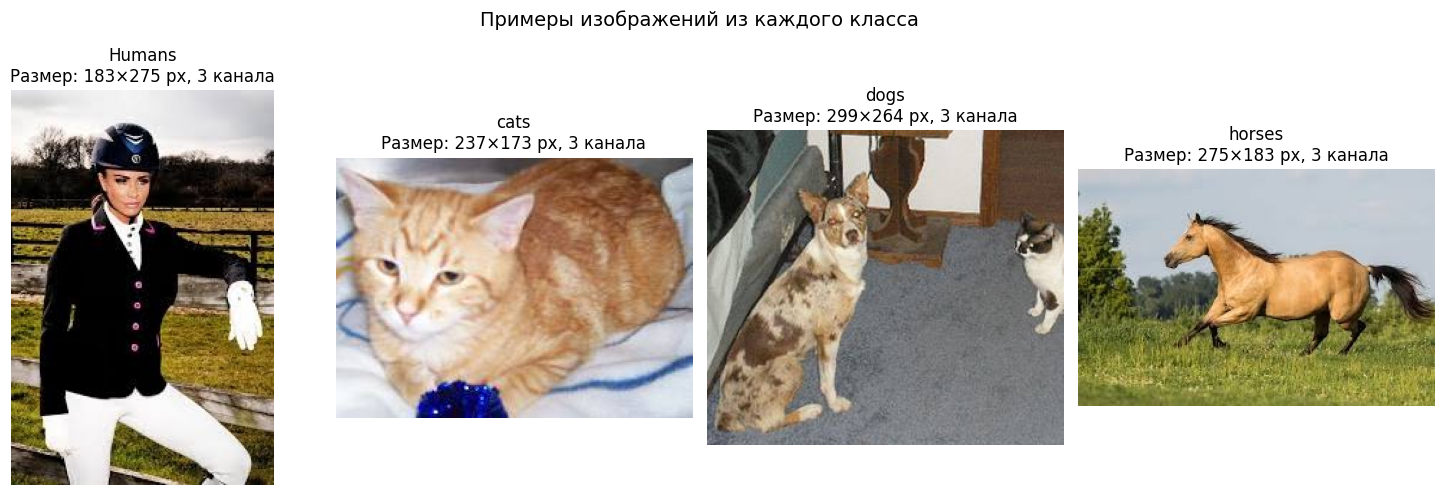

In [5]:
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(cls_path)[0]  # Берём первое изображение
    img = cv2.imread(os.path.join(cls_path, img_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV читает в BGR, matplotlib ожидает RGB

    axes[i].imshow(img_rgb)
    axes[i].set_title(f'{cls}\nРазмер: {img.shape[1]}×{img.shape[0]} px, {img.shape[2]} канала')
    axes[i].axis('off')

plt.suptitle('Примеры изображений из каждого класса', fontsize=14)
plt.tight_layout()
plt.show()

#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [18]:
IMG_SIZE = 128          # Ширина и высота изображения в пикселях
INPUT_DIM = IMG_SIZE * IMG_SIZE * 3  # Общее число значений: ширина × высота × 3 канала (RGB)

print(f"Целевой размер изображения: {IMG_SIZE}×{IMG_SIZE} пикселей")
print(f"Количество каналов: 3 (цветное изображение)")
print(f"Размерность входного вектора: {IMG_SIZE} × {IMG_SIZE} × 3 = {INPUT_DIM}")

Целевой размер изображения: 128×128 пикселей
Количество каналов: 3 (цветное изображение)
Размерность входного вектора: 128 × 128 × 3 = 49152


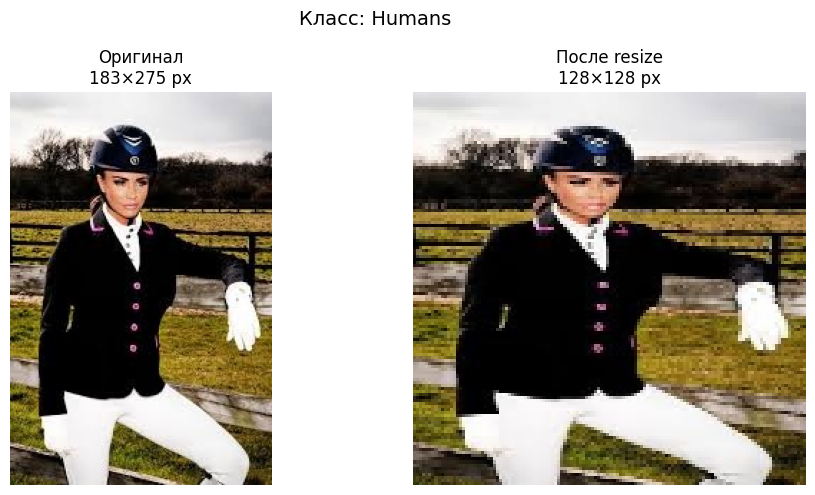

In [19]:
# Берём одно изображение для демонстрации
sample_cls = classes[0]
sample_dir = os.path.join(DATASET_PATH, sample_cls)
sample_path = os.path.join(sample_dir, os.listdir(sample_dir)[0])

sample_img = cv2.imread(sample_path)
sample_resized = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Оригинал\n{sample_img.shape[1]}×{sample_img.shape[0]} px')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(sample_resized, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'После resize\n{IMG_SIZE}×{IMG_SIZE} px')
axes[1].axis('off')

plt.suptitle(f'Класс: {sample_cls}', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Разворачиваем изображение в одномерный вектор
sample_flat = sample_resized.flatten()

print(f"Форма изображения:       {sample_resized.shape}  →  (высота, ширина, каналы)")
print(f"Форма вектора:           {sample_flat.shape}  →  одномерный вектор")
print(f"Количество элементов:    {len(sample_flat)}")
print(f"Первые 12 значений:     {sample_flat[:12]}")
print(f"Диапазон значений:      от {sample_flat.min()} до {sample_flat.max()}")

Форма изображения:       (128, 128, 3)  →  (высота, ширина, каналы)
Форма вектора:           (49152,)  →  одномерный вектор
Количество элементов:    49152
Первые 12 значений:     [228 223 224 229 224 225 230 225 226 230 225 226]
Диапазон значений:      от 0 до 255


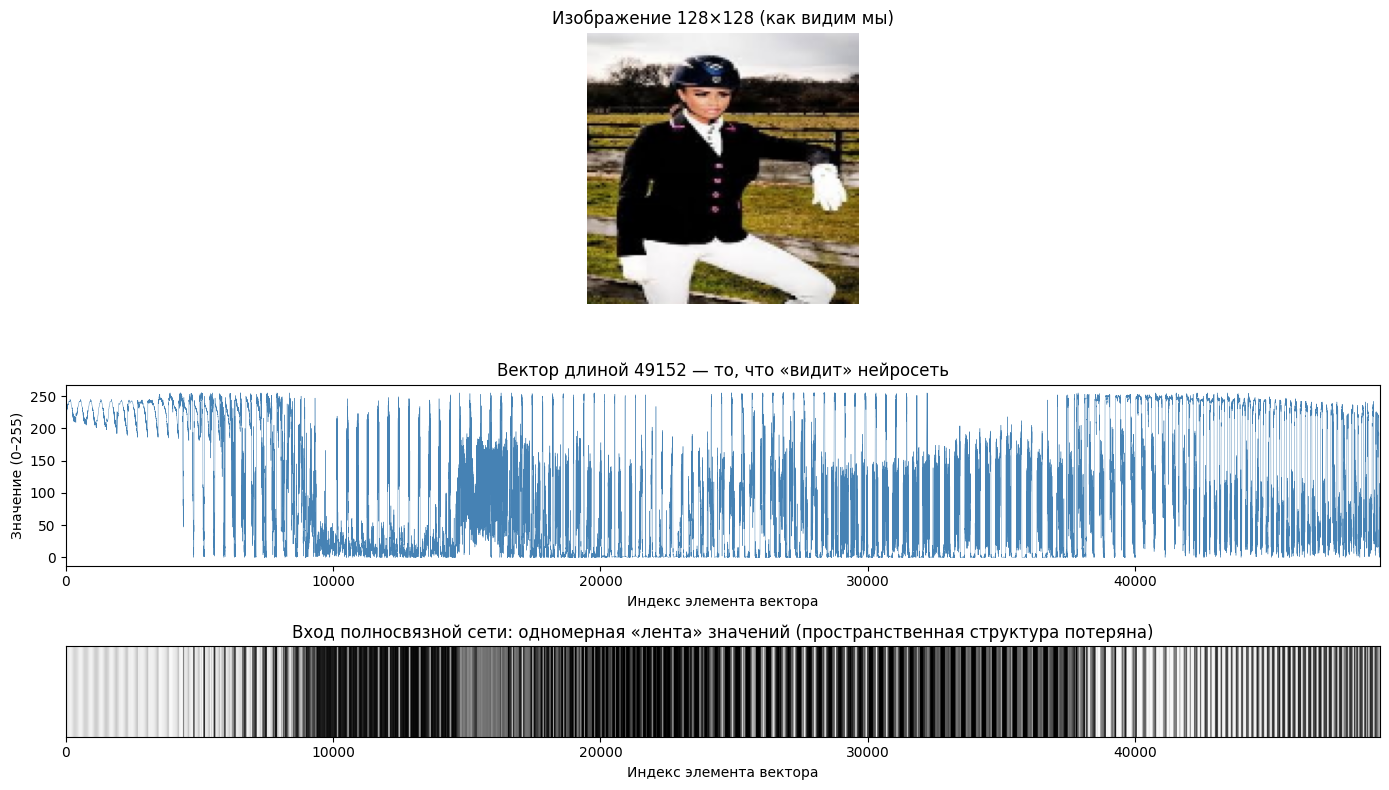

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 2, 1]})

# Исходное сжатое изображение
axes[0].imshow(cv2.cvtColor(sample_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Изображение {IMG_SIZE}×{IMG_SIZE} (как видим мы)')
axes[0].axis('off')

# Вектор — то, что видит нейросеть (график)
axes[1].plot(sample_flat, linewidth=0.3, color='steelblue')
axes[1].set_title(f'Вектор длиной {len(sample_flat)} — то, что «видит» нейросеть')
axes[1].set_xlabel('Индекс элемента вектора')
axes[1].set_ylabel('Значение (0–255)')
axes[1].set_xlim(0, len(sample_flat))

# Вектор как "лента пикселей" — буквальное представление входа нейросети
# Reshape в одну строку для визуализации как heatmap
vector_2d = sample_flat.reshape(1, -1)
axes[2].imshow(vector_2d, aspect='auto', cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Вход полносвязной сети: одномерная «лента» значений (пространственная структура потеряна)')
axes[2].set_xlabel('Индекс элемента вектора')
axes[2].set_yticks([])  # Убираем ось Y, так как это одна строка

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import random
from imutils import paths
from tqdm import tqdm

# Получаем список всех путей к изображениям
imagePaths = sorted(list(paths.list_images(DATASET_PATH)))
random.seed(42)
random.shuffle(imagePaths)  # Перемешиваем для случайного порядка

data = []
labels_str = []

for imagePath in tqdm(imagePaths, desc="Загрузка изображений", unit="img", colour="green"):
    try:
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).flatten()
        data.append(image)
        # Метка класса — это имя родительской папки
        label = imagePath.split(os.path.sep)[-2]
        labels_str.append(label)
    except:
        continue  # Пропускаем битые файлы

# Преобразуем в numpy-массивы и нормализуем пиксели
data = np.array(data, dtype="float") / 255.0
labels_str = np.array(labels_str)

Загрузка изображений: 100%|██████████| 808/808 [00:00<00:00, 1241.11img/s]


In [23]:
# Проверяем, что данные загружены успешно

print(f"   Массив изображений:  {data.shape}  →  ({data.shape[0]} изображений × {data.shape[1]} признаков)")
print(f"   Массив меток:        {labels_str.shape}")
print(f"   Уникальные классы:   {np.unique(labels_str)}")
print(f"   Диапазон значений:   [{data.min():.1f}, {data.max():.1f}]  (после нормализации)")

   Массив изображений:  (808, 49152)  →  (808 изображений × 49152 признаков)
   Массив меток:        (808,)
   Уникальные классы:   ['Humans' 'cats' 'dogs' 'horses']
   Диапазон значений:   [0.0, 1.0]  (после нормализации)


#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [24]:
lb = LabelBinarizer()
labels = lb.fit_transform(labels_str)

print(f"Классы (в алфавитном порядке): {lb.classes_}")
print(f"Форма массива меток: {labels.shape}  →  ({labels.shape[0]} меток × {labels.shape[1]} класса)")
print()
print("Примеры кодирования:")
for cls in lb.classes_:
    idx = np.where(labels_str == cls)[0][0]
    print(f"  '{cls}'  →  {labels[idx]}")

Классы (в алфавитном порядке): ['Humans' 'cats' 'dogs' 'horses']
Форма массива меток: (808, 4)  →  (808 меток × 4 класса)

Примеры кодирования:
  'Humans'  →  [1 0 0 0]
  'cats'  →  [0 1 0 0]
  'dogs'  →  [0 0 1 0]
  'horses'  →  [0 0 0 1]


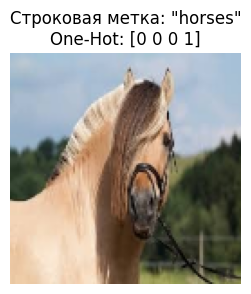

In [25]:
sample_idx = 0

# Восстановим изображение
img_check = (data[sample_idx].reshape(IMG_SIZE, IMG_SIZE, 3) * 255).astype(np.uint8)

plt.figure(figsize=(3, 3))
plt.imshow(cv2.cvtColor(img_check, cv2.COLOR_BGR2RGB))
plt.title(f'Строковая метка: "{labels_str[sample_idx]}"\nOne-Hot: {labels[sample_idx]}')
plt.axis('off')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

trainX, testX, trainY, testY = train_test_split(
    data, labels, test_size=0.25, random_state=42
)

print(f"Обучающая выборка:  {trainX.shape[0]} изображений,  матрица: {trainX.shape}")
print(f"Тестовая выборка:   {testX.shape[0]} изображений,  матрица: {testX.shape}")
print(f"Метки обучающие:    {trainY.shape}")
print(f"Метки тестовые:     {testY.shape}")

Обучающая выборка:  606 изображений,  матрица: (606, 49152)
Тестовая выборка:   202 изображений,  матрица: (202, 49152)
Метки обучающие:    (606, 4)
Метки тестовые:     (202, 4)


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

num_classes = len(lb.classes_)

model = Sequential()
model.add(Dense(1024, input_shape=(INPUT_DIM,), activation="relu"))
model.add(Dense(512, activation="relu"))
model.add(Dense(256, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,989,828 (194.51 MB)

 Trainable params: 50,989,828 (194.51 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [28]:
from tensorflow.keras.optimizers import Adam

# ГИПЕРПАРАМЕТРЫ

INIT_LR = 0.000001       # Скорость обучения
EPOCHS = 100           # Количество эпох
BATCH_SIZE = 8      # Размер батча

opt = Adam(learning_rate=INIT_LR)

#### 5.3. Компилируем модель:

In [29]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.3531 - loss: 1.3486 - val_accuracy: 0.3069 - val_loss: 1.3721
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4686 - loss: 1.2259 - val_accuracy: 0.3416 - val_loss: 1.3028
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5281 - loss: 1.1677 - val_accuracy: 0.3960 - val_loss: 1.3003
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5528 - loss: 1.1270 - val_accuracy: 0.3564 - val_loss: 1.2860
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5809 - loss: 1.0822 - val_accuracy: 0.3861 - val_loss: 1.2489
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6155 - loss: 1.0465 - val_accuracy: 0.4158 - val_loss: 1.2574
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6353 - loss: 1.0060 - val_accuracy: 0.4109 - val_loss: 1.2435
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6634 - loss: 0.9726 - val_accuracy: 0.

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [33]:
# Импортируем колбэки
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard


# ----- EarlyStopping -----
# Останавливает обучение, если валидационная метрика не улучшается
early_stopping = EarlyStopping(
    monitor='val_loss',          # Метрика для отслеживания
    patience=50,                 # Количество эпох без улучшения до остановки
    min_delta=0.001,             # Минимальное изменение для считывания как улучшение
    restore_best_weights=True,   # Восстановить веса лучшей модели
    verbose=1                    # Выводить сообщения
)

# ----- ModelCheckpoint -----
# Сохраняет модель при улучшении метрики
checkpoint = ModelCheckpoint(
    filepath="best_model.h5",    # Путь для сохранения
    monitor="val_accuracy",      # Метрика для отслеживания
    save_best_only=True,         # Сохранять только лучшую модель
    save_weights_only=False,     # Сохранять всю модель (не только веса)
    verbose=1,                    # Выводить сообщения
    mode="max"
)

# ----- ReduceLROnPlateau -----
# Уменьшает скорость обучения при стагнации
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',          # Метрика для отслеживания
    factor=0.5,                  # Коэффициент уменьшения LR (new_lr = lr * factor)
    patience=5,                  # Количество эпох без улучшения
    min_lr=1e-7,                 # Минимальное значение LR
    verbose=1                    # Выводить сообщения
)

# ----- TensorBoard -----
# Логирование для визуализации
tensorboard = TensorBoard(
    log_dir='./logs',            # Директория для логов
    histogram_freq=1             # Частота записи гистограмм
)

# Список всех колбэков для обучения
callbacks_list = [early_stopping, checkpoint, reduce_lr]

#### 6.2. Запустим процесс обучения модели:

In [34]:
# Гиперпараметры обучения
INIT_LR = 0.000001        # Начальная скорость обучения
EPOCHS = 200           # Максимальное количество эпох
BATCH_SIZE = 8        # Размер батча

# Компилируем модель
opt = Adam(learning_rate=INIT_LR)

model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

# Запускаем обучение с колбэками
H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list  # Передаем список колбэков
)

Epoch 1/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7504 - loss: 0.8466
Epoch 1: val_accuracy improved from None to 0.43564, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.7591 - loss: 0.8099 - val_accuracy: 0.4356 - val_loss: 1.2462 - learning_rate: 1.0000e-06
Epoch 2/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7488 - loss: 0.8096
Epoch 2: val_accuracy improved from 0.43564 to 0.50495, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.7475 - loss: 0.8168 - val_accuracy: 0.5050 - val_loss: 1.1494 - learning_rate: 1.0000e-06
Epoch 3/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7842 - loss: 0.7930
Epoch 3: val_accuracy did not improve from 0.50495
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7508 - loss: 0.8003 - val_accuracy: 0.4752 - val_loss: 1.1463 - learning_rate: 1.0000e-06
Epoch 4/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7479 - loss: 0.7959
Epoch 4: val_accuracy did not improve from 0.50495
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7657 - loss: 0.8004 - val_accuracy: 0.4901 - val_loss: 1.1641 - learning_rate: 1.0000e-06
Epoch 5/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7646 - loss: 0.7846
Epoch 5: val_accuracy did not improve from 0.50495
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7591 - loss: 0.7918 - val_accuracy: 0.5050 - val_loss


Epoch 10: finished saving model to best_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.7756 - loss: 0.7667 - val_accuracy: 0.5149 - val_loss: 1.1340 - learning_rate: 1.0000e-06
Epoch 11/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7569 - loss: 0.7750
Epoch 11: val_accuracy did not improve from 0.51485
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7789 - loss: 0.7544 - val_accuracy: 0.4356 - val_loss: 1.2315 - learning_rate: 1.0000e-06
Epoch 12/200
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7324 - loss: 0.7774
Epoch 12: val_accuracy did not improve from 0.51485
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7508 - loss: 0.7650 - val_accuracy: 0.4950 - val_loss: 1.1456 - learning_rate: 1.0000e-06
Epoch 13/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8202 - loss: 0.7088
Epoch 13: val_accuracy did not improve from 0.51485
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7772 - loss: 0.7436 - val_accuracy: 0.5050 - 


Epoch 20: finished saving model to best_model.h5

Epoch 20: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.7970 - loss: 0.7121 - val_accuracy: 0.5248 - val_loss: 1.1428 - learning_rate: 1.0000e-06
Epoch 21/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8324 - loss: 0.6862
Epoch 21: val_accuracy did not improve from 0.52475
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8003 - loss: 0.6979 - val_accuracy: 0.4950 - val_loss: 1.1205 - learning_rate: 5.0000e-07
Epoch 22/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7907 - loss: 0.7097
Epoch 22: val_accuracy did not improve from 0.52475
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7954 - loss: 0.7001 - val_accuracy: 0.4901 - val_loss: 1.1211 - learning_rate: 5.0000e-07
Epoch 23/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7926 - loss: 0.7117
Epoch 23: val_accuracy did not improve from 0.52475
76/76 ━━━━━━━━━━━━━━━

#### 6.3. Загружаем лучшую модель:

In [35]:
model.save("best_model.h5")

In [36]:
from tensorflow.keras.models import load_model

# Загружаем лучшую модель, сохраненную колбэком ModelCheckpoint
model = load_model("best_model.h5")
print("Лучшая модель загружена из best_model.h5")

Лучшая модель загружена из best_model.h5


### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [37]:
preds = model.predict(testX, batch_size=32)

print("\n" + "="*50)
print("ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print("="*50)
print(classification_report(
    testY.argmax(axis=1),
    preds.argmax(axis=1),
    target_names=lb.classes_
))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

ОТЧЕТ ПО КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

      Humans       0.54      0.53      0.53        51
        cats       0.44      0.44      0.44        59
        dogs       0.41      0.33      0.37        54
      horses       0.57      0.74      0.64        38

    accuracy                           0.49       202
   macro avg       0.49      0.51      0.50       202
weighted avg       0.48      0.49      0.48       202



#### 7.2. Выведем матрицу ошибок

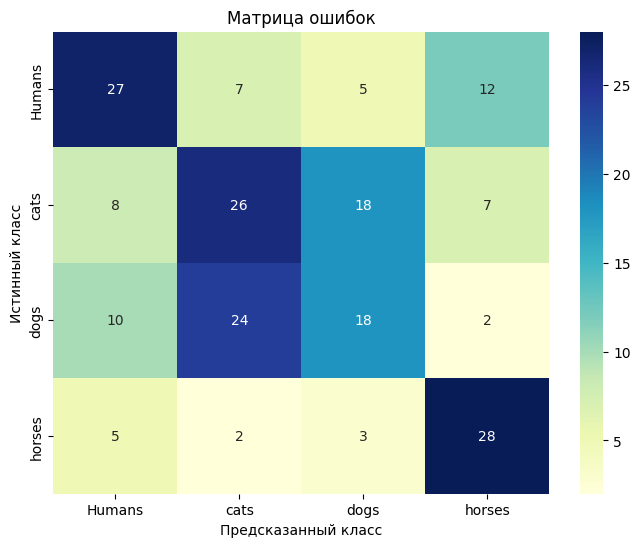

In [38]:
# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report, confusion_matrix
# Импортируем seaborn для визуализации
import seaborn as sns

Y_pred = preds.argmax(axis=1)
Y_true = testY.argmax(axis=1)

conf_mat = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

#### 7.3. Отобразим график обучения

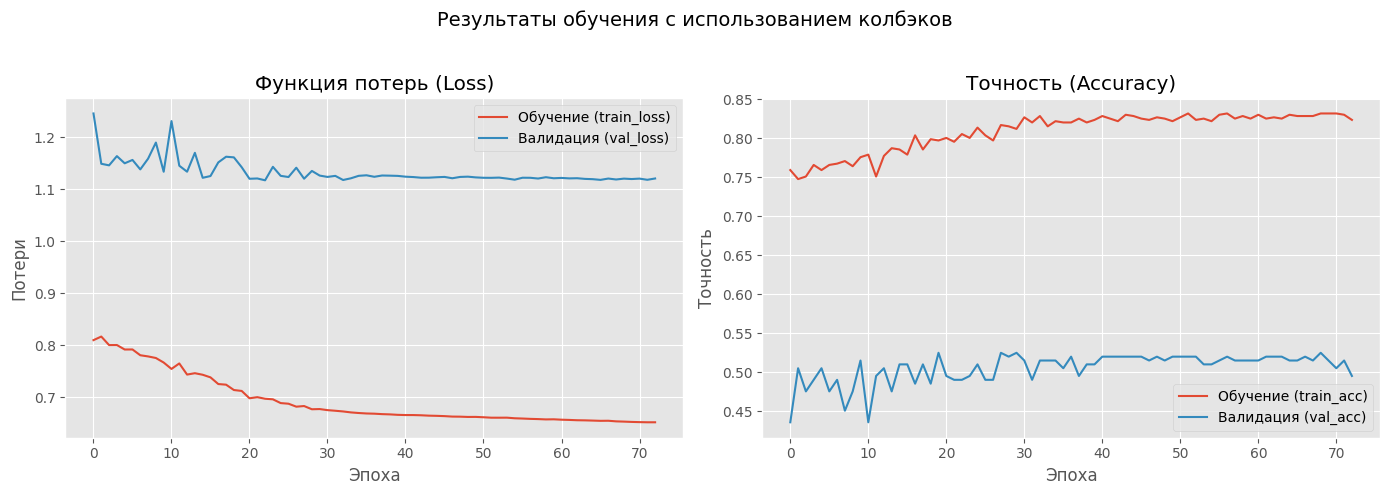

In [39]:
epochs_range = np.arange(0, len(H.history['loss']))
plt.style.use("ggplot")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
ax1.plot(epochs_range, H.history["loss"], label="Обучение (train_loss)")
ax1.plot(epochs_range, H.history["val_loss"], label="Валидация (val_loss)")
ax1.set_title("Функция потерь (Loss)")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Потери")
ax1.legend()

# График точности
ax2.plot(epochs_range, H.history["accuracy"], label="Обучение (train_acc)")
ax2.plot(epochs_range, H.history["val_accuracy"], label="Валидация (val_acc)")
ax2.set_title("Точность (Accuracy)")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Точность")
ax2.legend()

plt.suptitle("Результаты обучения с использованием колбэков", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 8. Сохранение модели и меток классов:

In [40]:
def save_model_and_labels(model, lb, model_path="model.h5", labels_path="label_bin"):
    """
    Сохраняет модель машинного обучения и метки классов на диск.
    """
    model.save(model_path, save_format="h5")

    with open(labels_path, "wb") as f:
        f.write(pickle.dumps(lb))

    print(f"Модель сохранена: {model_path}")
    print(f"Метки сохранены: {labels_path}")

model_path = "model.h5"
labels_path = "label_bin"


save_model_and_labels(model, lb, model_path, labels_path)

Модель сохранена: model.h5
Метки сохранены: label_bin


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [41]:
from google.colab import files
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [42]:
def upload_image():
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    image = cv2.imread(filename)
    return filename, image
def preprocess_image(image, img_size):
    image_resized = cv2.resize(image, (img_size, img_size))
    image_flat = image_resized.flatten().astype("float32") / 255.0
    image_processed = image_flat.reshape((1, -1))
    return image_processed

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [43]:
def load_trained_model(model_path, classes_path):
    model = load_model(model_path, compile=False)
    class_names = np.load(classes_path, allow_pickle=True)
    return model, class_names
def make_prediction(model, image_processed):
    preds = model.predict(image_processed)
    idx = preds.argmax(axis=1)[0]
    confidence = preds[0][idx] * 100
    return preds, idx, confidence

### 10. Визуализируем интерфейс и произведем классификацию:

Загрузите изображение для проверки:


Saving человек 2.jpg to человек 2 (1).jpg



Загруженные классы: ['Humans' 'cats' 'dogs' 'horses']



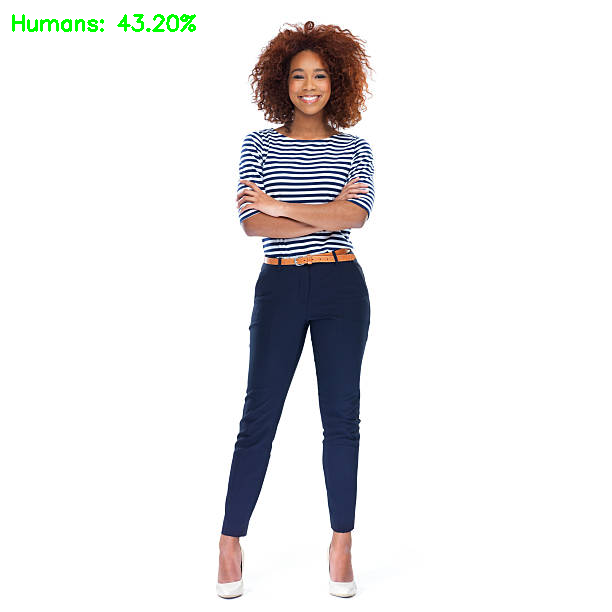


📊 Вероятности по классам:
        Humans:  43.20%  ████████████
          cats:  28.88%  ████████
          dogs:  17.16%  █████
        horses:  10.76%  ███


In [50]:
import pickle
import numpy as np
import cv2

# Загружаем пользовательское изображение
print("Загрузите изображение для проверки:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Читаем изображение
image = cv2.imread(filename)
if image is None:
    print(f"Не удалось загрузить изображение: {filename}")
else:
    output = image.copy()

    # Подготавливаем изображение: resize -> flatten -> normalize
    image_processed = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).flatten().astype("float") / 255.0
    image_processed = image_processed.reshape((1, -1))  # Добавляем размерность батча

    # Загружаем сохранённую модель
    model = load_model("model.h5")

    with open("label_bin", "rb") as f:
        lb = pickle.load(f)  # Загружаем LabelBinarizer
    class_names = lb.classes_  # Получаем имена классов

    print(f"\nЗагруженные классы: {class_names}\n")

    # Получаем предсказание
    preds = model.predict(image_processed, verbose=0)
    i = preds.argmax(axis=1)[0]

    # Отображаем результат
    label = class_names[i]
    confidence = preds[0][i] * 100
    text = f"{label}: {confidence:.2f}%"

    cv2.putText(output, text, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)  # Зеленый цвет
    cv2_imshow(output)

    # Выводим вероятности для всех классов
    print(f"\n📊 Вероятности по классам:")
    for cls, prob in zip(class_names, preds[0]):
        bar = '█' * int(prob * 30)
        print(f"  {cls:>12s}: {prob*100:6.2f}%  {bar}")